# 🍳 Optimizer Cookbook — Chapter 07: Final Head-to-Head Comparison

**Previous:** `06_radam.ipynb` — RAdam  

---

This is the final chapter. All 7 optimizers have been trained on the **same model, same dataset, same seed**.  
This notebook loads every saved CSV log and produces the full comparison suite:

| Section | What it shows |
|---|---|
| § 1 | Full loss & accuracy curves — all 7 on one chart |
| § 2 | Final ranked leaderboard with statistical summary |
| § 3 | Convergence speed — how many epochs to hit 60%, 65%, 70% |
| § 4 | Generalisation gap — train vs val accuracy spread |
| § 5 | Compute efficiency — best accuracy per wall-clock second |
| § 6 | Radar chart — multi-dimensional optimizer profile |
| § 7 | Decision flowchart — which optimizer to pick |
| § 8 | Final cheat sheet table |

---
## 0. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import os

RESULTS_DIR = '../results/logs'
PLOTS_DIR   = '../results/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Optimizer registry ───────────────────────────────────────
OPTIMIZERS = [
    ('Vanilla SGD',    'SGD_baseline_log.csv',  '#aaaaaa',      ':' ),
    ('SGD + Momentum', 'SGD_Momentum_log.csv',  '#4e79a7',      '--'),
    ('Adagrad',        'Adagrad_log.csv',        '#f28e2b',      '--'),
    ('RMSprop',        'RMSprop_log.csv',        '#59a14f',      '--'),
    ('Adam',           'Adam_log.csv',           '#e15759',      '-' ),
    ('AdamW',          'AdamW_log.csv',          '#b07aa1',      '-' ),
    ('RAdam',          'RAdam_log.csv',          '#76b7b2',      '-' ),
]

# Load all available logs
data = {}
missing = []
for name, fname, color, style in OPTIMIZERS:
    path = f'{RESULTS_DIR}/{fname}'
    if os.path.exists(path):
        data[name] = {'df': pd.read_csv(path), 'color': color, 'style': style}
    else:
        missing.append(name)

print(f'Loaded  : {list(data.keys())}')
if missing:
    print(f'Missing : {missing} — run the corresponding notebooks first')

Loaded  : ['Vanilla SGD', 'SGD + Momentum', 'Adagrad', 'RMSprop', 'Adam', 'AdamW', 'RAdam']


---
## § 1 — Full Training Curves: All Optimizers

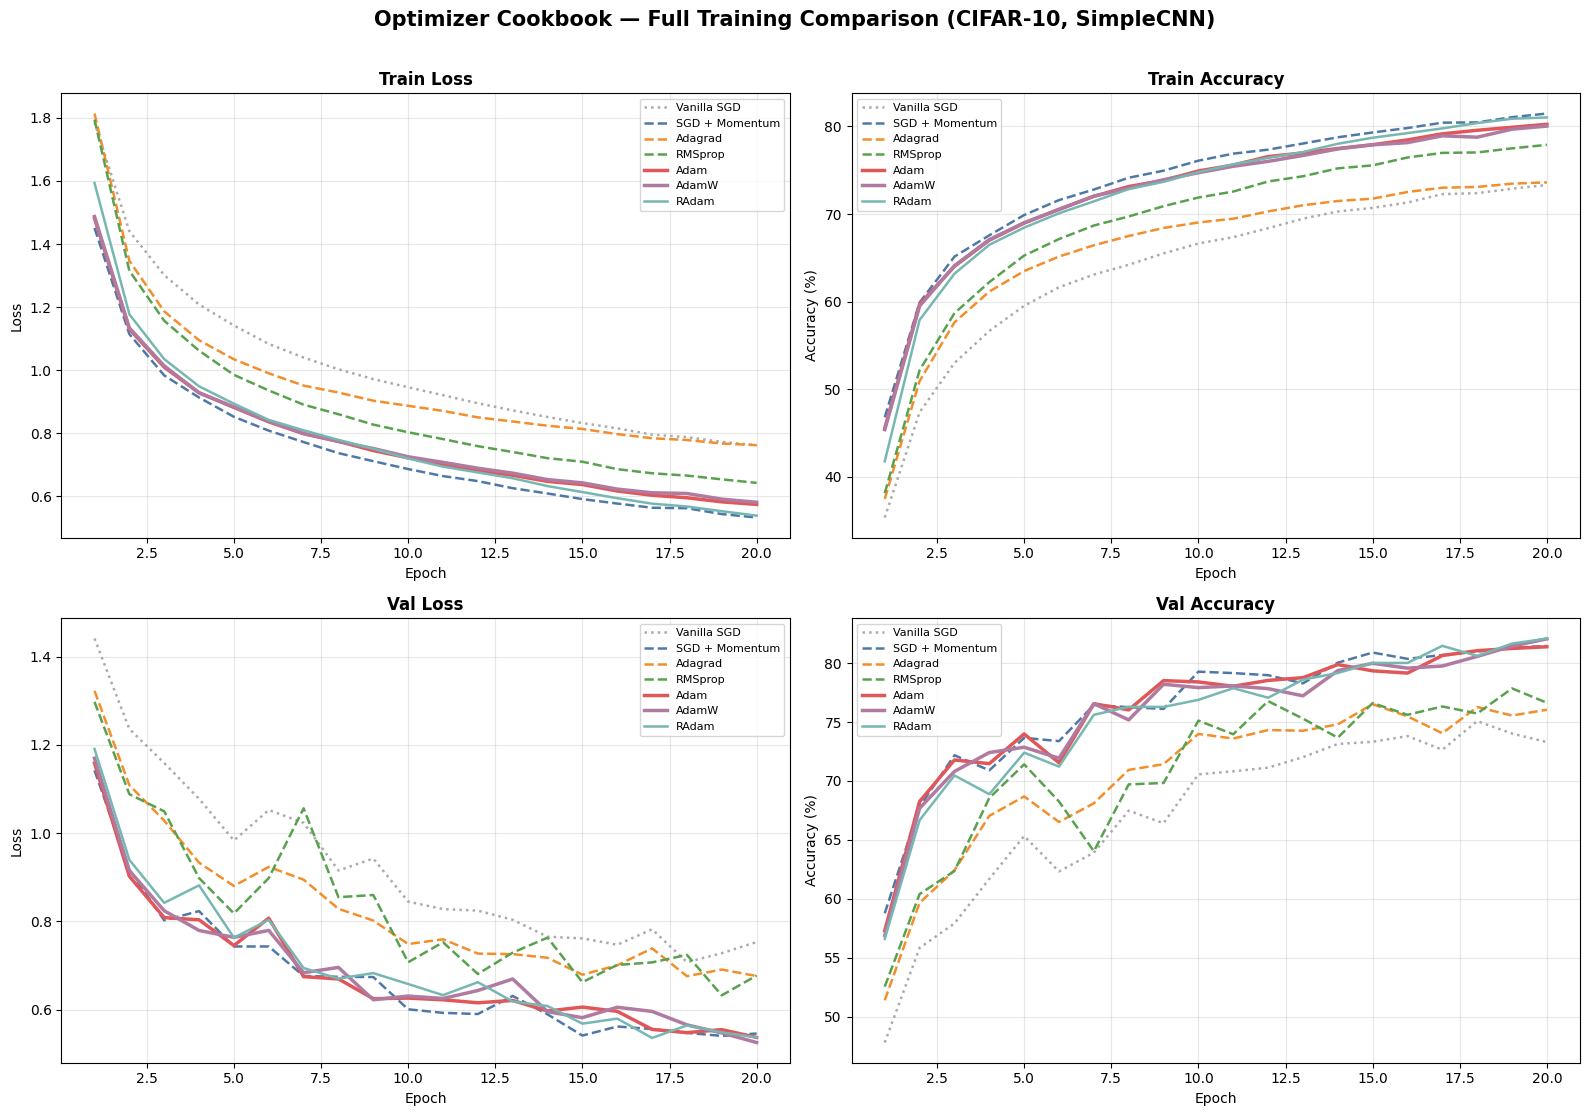

Saved → results/plots/final_all_curves.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Optimizer Cookbook — Full Training Comparison (CIFAR-10, SimpleCNN)',
             fontsize=15, fontweight='bold', y=1.01)

ax_tl, ax_ta = axes[0]
ax_vl, ax_va = axes[1]

for name, d in data.items():
    df    = d['df']
    c     = d['color']
    s     = d['style']
    lw    = 2.5 if name in ('Adam', 'AdamW') else 1.8
    ax_tl.plot(df['epoch'], df['train_loss'], label=name, color=c, linestyle=s, linewidth=lw)
    ax_ta.plot(df['epoch'], df['train_acc'],  label=name, color=c, linestyle=s, linewidth=lw)
    ax_vl.plot(df['epoch'], df['val_loss'],   label=name, color=c, linestyle=s, linewidth=lw)
    ax_va.plot(df['epoch'], df['val_acc'],    label=name, color=c, linestyle=s, linewidth=lw)

for ax, title, ylabel in [
    (ax_tl, 'Train Loss',     'Loss'),
    (ax_ta, 'Train Accuracy', 'Accuracy (%)'),
    (ax_vl, 'Val Loss',       'Loss'),
    (ax_va, 'Val Accuracy',   'Accuracy (%)'),
]:
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_all_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → results/plots/final_all_curves.png')

---
## § 2 — Final Ranked Leaderboard

In [4]:
rows = []
for name, d in data.items():
    df   = d['df']
    best = df.loc[df['val_acc'].idxmax()]
    rows.append({
        'Optimizer'     : name,
        'Best Val Acc'  : round(best['val_acc'],  2),
        'Best Val Loss' : round(best['val_loss'], 4),
        'Best Epoch'    : int(best['epoch']),
        'Final Val Acc' : round(df['val_acc'].iloc[-1], 2),
        'Avg Time (s)'  : round(df['time_s'].mean(), 1),
    })

leaderboard = pd.DataFrame(rows).sort_values('Best Val Acc', ascending=False).reset_index(drop=True)
leaderboard.index += 1

print('\n' + '='*75)
print('  OPTIMIZER COOKBOOK — FINAL LEADERBOARD')
print('='*75)
print(leaderboard.to_string())
print('='*75)
winner = leaderboard.iloc[0]
print(f"\n🏆 Winner: {winner['Optimizer']} @ {winner['Best Val Acc']}% (Epoch {winner['Best Epoch']})")


  OPTIMIZER COOKBOOK — FINAL LEADERBOARD
        Optimizer  Best Val Acc  Best Val Loss  Best Epoch  Final Val Acc  Avg Time (s)
1           RAdam         82.08         0.5376          20          82.08          38.9
2           AdamW         82.05         0.5257          20          82.05          34.3
3  SGD + Momentum         81.45         0.5461          20          81.45          17.2
4            Adam         81.38         0.5373          20          81.38          19.6
5         RMSprop         77.85         0.6326          19          76.63          25.7
6         Adagrad         76.51         0.6794          15          76.04          31.4
7     Vanilla SGD         75.08         0.7077          18          73.30          18.1

🏆 Winner: RAdam @ 82.08% (Epoch 20)


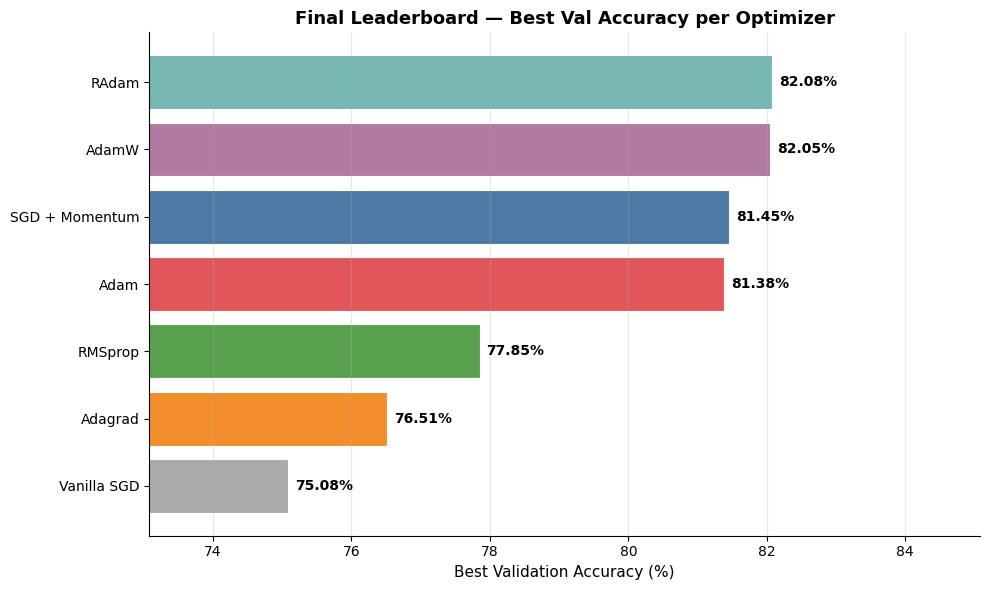

In [5]:
# Visual leaderboard bar chart
lb = leaderboard.sort_values('Best Val Acc')
colors_map = {d[0]: d[2] for d in OPTIMIZERS}
bar_colors = [colors_map.get(n, '#888888') for n in lb['Optimizer']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(lb['Optimizer'], lb['Best Val Acc'], color=bar_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, lb['Best Val Acc']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Best Validation Accuracy (%)', fontsize=11)
ax.set_title('Final Leaderboard — Best Val Accuracy per Optimizer', fontsize=13, fontweight='bold')
ax.set_xlim(lb['Best Val Acc'].min() - 2, lb['Best Val Acc'].max() + 3)
ax.grid(axis='x', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_leaderboard_bar.png', dpi=130, bbox_inches='tight')
plt.show()

---
## § 3 — Convergence Speed

How many epochs does each optimizer need to first hit 60%, 65%, and 70% val accuracy?

     Optimizer  Epoch to 60.0%  Epoch to 65.0%  Epoch to 70.0%
   Vanilla SGD               4               5              10
SGD + Momentum               2               2               3
       Adagrad               3               4               8
       RMSprop               2               4               5
          Adam               2               2               3
         AdamW               2               2               3
         RAdam               2               2               3


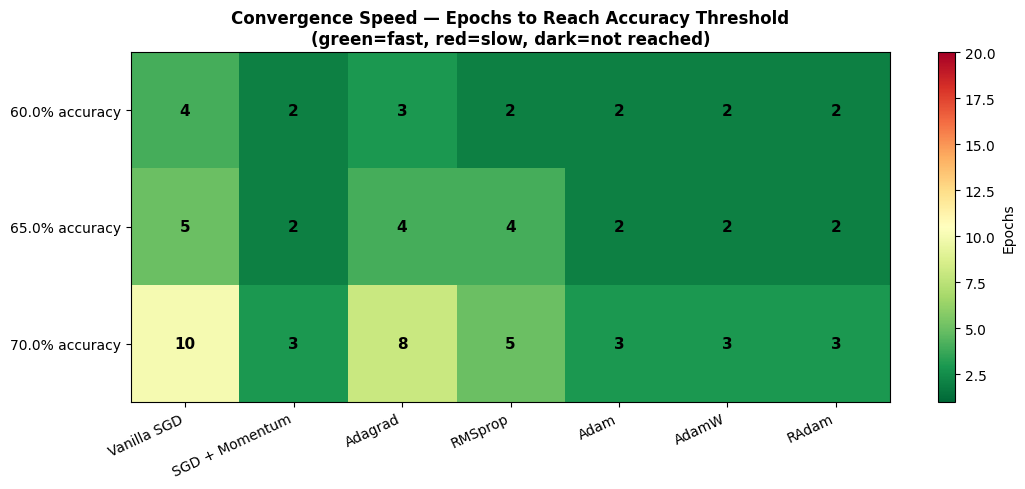

In [6]:
thresholds = [60.0, 65.0, 70.0]

conv_rows = []
for name, d in data.items():
    df   = d['df']
    row  = {'Optimizer': name}
    for t in thresholds:
        reached = df[df['val_acc'] >= t]
        row[f'Epoch to {t}%'] = int(reached['epoch'].iloc[0]) if not reached.empty else 'Not reached'
    conv_rows.append(row)

conv_df = pd.DataFrame(conv_rows)
print(conv_df.to_string(index=False))

# Heatmap-style visualisation
fig, ax = plt.subplots(figsize=(11, 5))
thresh_labels = [f'Epoch to {t}%' for t in thresholds]
optimizers    = conv_df['Optimizer'].tolist()

matrix = []
for _, row in conv_df.iterrows():
    matrix.append([row[c] if isinstance(row[c], (int, float)) else 25 for c in thresh_labels])
matrix = np.array(matrix, dtype=float)

im = ax.imshow(matrix.T, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=20)
ax.set_xticks(range(len(optimizers))); ax.set_xticklabels(optimizers, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(thresh_labels))); ax.set_yticklabels([f'{t}% accuracy' for t in thresholds], fontsize=10)
ax.set_title('Convergence Speed — Epochs to Reach Accuracy Threshold\n(green=fast, red=slow, dark=not reached)',
             fontsize=12, fontweight='bold')

for i in range(len(optimizers)):
    for j in range(len(thresholds)):
        val = conv_df.iloc[i][thresh_labels[j]]
        txt = str(val) if val != 25 else '—'
        ax.text(i, j, txt, ha='center', va='center', fontsize=11,
                fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='Epochs')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_convergence_speed.png', dpi=130, bbox_inches='tight')
plt.show()

---
## § 4 — Generalisation Gap

Train accuracy − Val accuracy at the final epoch.  
A larger gap = more overfitting.

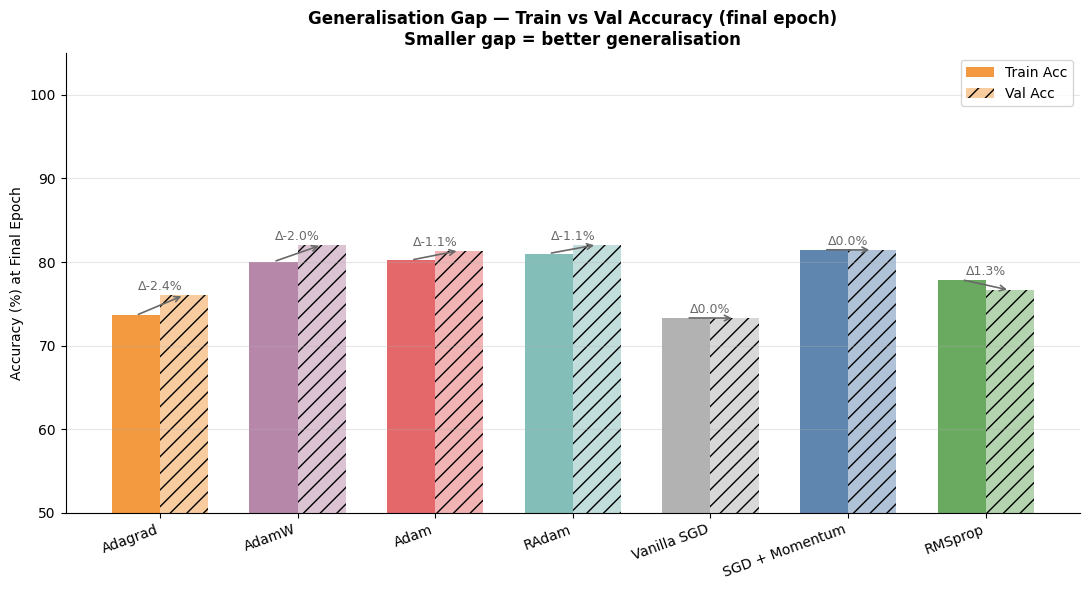


Generalisation gap (sorted best → worst):
     Optimizer  Train Acc  Val Acc   Gap
       Adagrad     73.616    76.04 -2.42
         AdamW     80.038    82.05 -2.01
          Adam     80.242    81.38 -1.14
         RAdam     81.022    82.08 -1.06
   Vanilla SGD     73.314    73.30  0.01
SGD + Momentum     81.470    81.45  0.02
       RMSprop     77.896    76.63  1.27


In [7]:
gap_rows = []
for name, d in data.items():
    df       = d['df']
    last     = df.iloc[-1]
    gap      = last['train_acc'] - last['val_acc']
    gap_rows.append({'Optimizer': name, 'Train Acc': last['train_acc'],
                     'Val Acc': last['val_acc'], 'Gap': round(gap, 2)})

gap_df = pd.DataFrame(gap_rows).sort_values('Gap')

fig, ax = plt.subplots(figsize=(11, 6))
x      = np.arange(len(gap_df))
width  = 0.35
names  = gap_df['Optimizer'].tolist()
bar_c  = [colors_map.get(n, '#888') for n in names]

b1 = ax.bar(x - width/2, gap_df['Train Acc'], width, label='Train Acc', color=bar_c, alpha=0.9)
b2 = ax.bar(x + width/2, gap_df['Val Acc'],   width, label='Val Acc',   color=bar_c, alpha=0.45, hatch='//')

for i, (tr, vl, gap) in enumerate(zip(gap_df['Train Acc'], gap_df['Val Acc'], gap_df['Gap'])):
    ax.annotate('', xy=(i + width/2, vl), xytext=(i - width/2, tr),
                arrowprops=dict(arrowstyle='->', color='dimgray', lw=1.2))
    ax.text(i, max(tr, vl) + 0.6, f'Δ{gap:.1f}%', ha='center', fontsize=9, color='dimgray')

ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%) at Final Epoch'); ax.set_ylim(50, 105)
ax.set_title('Generalisation Gap — Train vs Val Accuracy (final epoch)\nSmaller gap = better generalisation',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_generalisation_gap.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nGeneralisation gap (sorted best → worst):')
print(gap_df[['Optimizer','Train Acc','Val Acc','Gap']].to_string(index=False))

---
## § 5 — Compute Efficiency

Best val accuracy per total wall-clock training time.  
A higher score means you get more accuracy per second of GPU time.

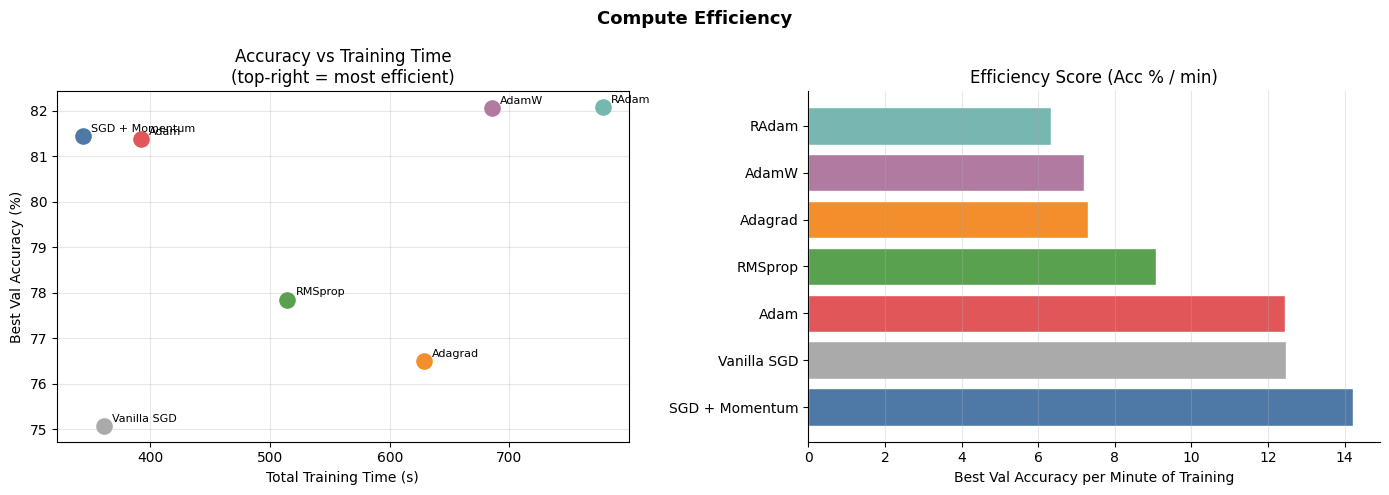

     Optimizer  Total Time (s)  Best Val Acc  Acc/min
SGD + Momentum           343.9         81.45   14.210
   Vanilla SGD           361.4         75.08   12.464
          Adam           392.2         81.38   12.451
       RMSprop           514.6         77.85    9.077
       Adagrad           628.4         76.51    7.305
         AdamW           685.1         82.05    7.186
         RAdam           777.8         82.08    6.332


In [8]:
eff_rows = []
for name, d in data.items():
    df           = d['df']
    total_time   = df['time_s'].sum()
    best_val_acc = df['val_acc'].max()
    efficiency   = best_val_acc / total_time * 60   # accuracy per minute
    eff_rows.append({'Optimizer': name, 'Total Time (s)': round(total_time, 1),
                     'Best Val Acc': round(best_val_acc, 2), 'Acc/min': round(efficiency, 3)})

eff_df = pd.DataFrame(eff_rows).sort_values('Acc/min', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Compute Efficiency', fontsize=13, fontweight='bold')

# Scatter: total time vs best accuracy
for _, row in eff_df.iterrows():
    c = colors_map.get(row['Optimizer'], '#888')
    ax1.scatter(row['Total Time (s)'], row['Best Val Acc'], color=c, s=120, zorder=3)
    ax1.annotate(row['Optimizer'], (row['Total Time (s)'], row['Best Val Acc']),
                 textcoords='offset points', xytext=(6, 3), fontsize=8)
ax1.set_xlabel('Total Training Time (s)'); ax1.set_ylabel('Best Val Accuracy (%)')
ax1.set_title('Accuracy vs Training Time\n(top-right = most efficient)'); ax1.grid(alpha=0.3)

# Bar: accuracy per minute
bar_c2 = [colors_map.get(n, '#888') for n in eff_df['Optimizer']]
ax2.barh(eff_df['Optimizer'], eff_df['Acc/min'], color=bar_c2, edgecolor='white')
ax2.set_xlabel('Best Val Accuracy per Minute of Training')
ax2.set_title('Efficiency Score (Acc % / min)')
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_compute_efficiency.png', dpi=130, bbox_inches='tight')
plt.show()
print(eff_df.to_string(index=False))

---
## § 6 — Radar Chart: Multi-Dimensional Optimizer Profile

Scores each optimizer across 5 dimensions:
- **Convergence Speed** — epochs to 70% (inverted: fewer = better)
- **Final Accuracy** — best val acc
- **Generalisation** — inverted train/val gap (smaller gap = higher score)
- **Stability** — consistency of val acc in last 5 epochs (lower std = higher score)
- **Efficiency** — accuracy per minute of training

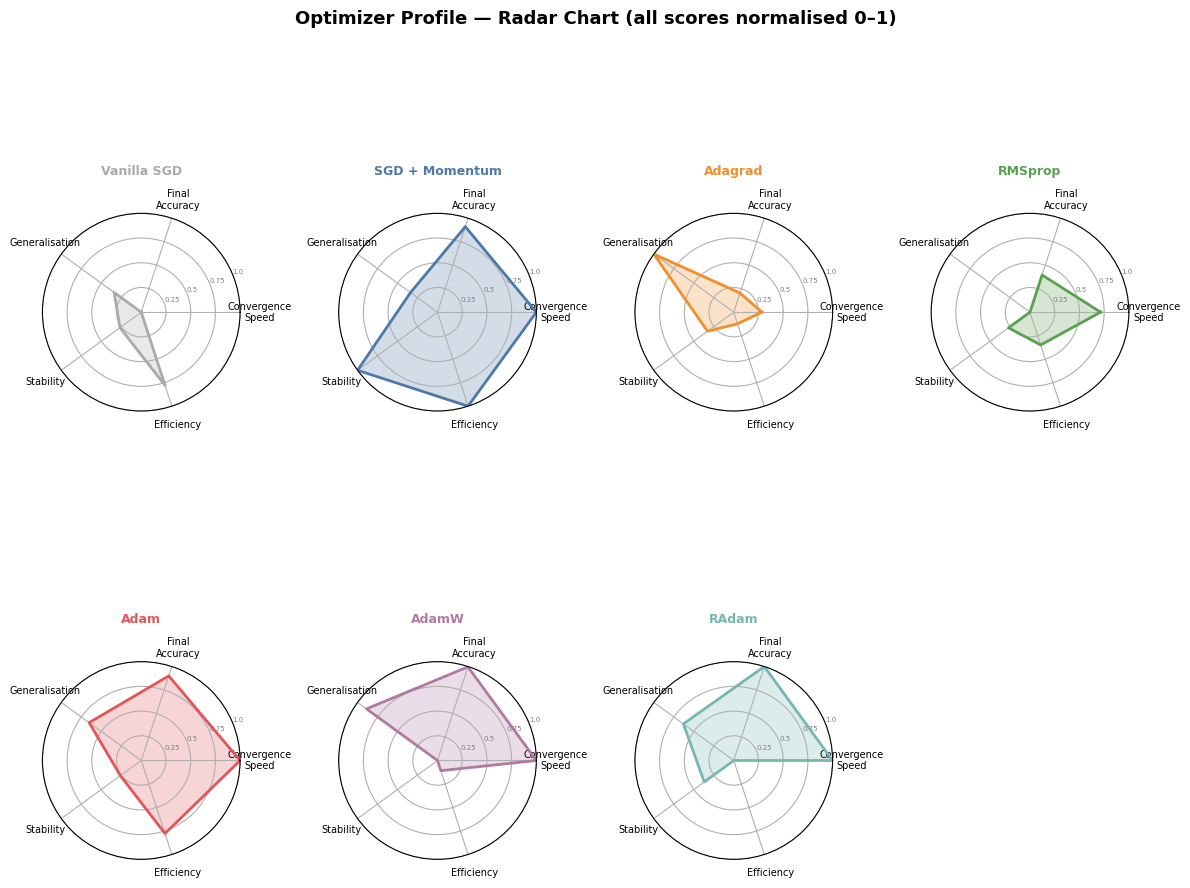

In [9]:
def minmax(arr):
    mn, mx = min(arr), max(arr)
    return [(v - mn) / (mx - mn + 1e-9) for v in arr]

names_list = list(data.keys())
N_OPT      = len(names_list)

speed_raw, acc_raw, gen_raw, stab_raw, eff_raw = [], [], [], [], []
for name in names_list:
    df   = data[name]['df']
    # convergence speed: epochs to 70% (25 if not reached)
    reached = df[df['val_acc'] >= 70.0]
    speed_raw.append(int(reached['epoch'].iloc[0]) if not reached.empty else 25)
    # final accuracy
    acc_raw.append(df['val_acc'].max())
    # generalisation gap (inverted)
    last = df.iloc[-1]
    gen_raw.append(last['train_acc'] - last['val_acc'])
    # stability: std of val_acc in last 5 epochs (inverted)
    stab_raw.append(df['val_acc'].tail(5).std())
    # efficiency: acc/min
    eff_raw.append(df['val_acc'].max() / df['time_s'].sum() * 60)

# Normalise — for speed and gap, lower is better so invert
speed_n = [1 - v for v in minmax(speed_raw)]
acc_n   = minmax(acc_raw)
gen_n   = [1 - v for v in minmax(gen_raw)]
stab_n  = [1 - v for v in minmax(stab_raw)]
eff_n   = minmax(eff_raw)

categories  = ['Convergence\nSpeed', 'Final\nAccuracy', 'Generalisation', 'Stability', 'Efficiency']
N_CATS      = len(categories)
angles      = [n / float(N_CATS) * 2 * np.pi for n in range(N_CATS)]
angles     += angles[:1]

fig = plt.figure(figsize=(12, 10))
fig.suptitle('Optimizer Profile — Radar Chart (all scores normalised 0–1)',
             fontsize=13, fontweight='bold', y=1.01)

# One subplot per optimizer (2 rows x 4 cols)
cols = 4
rows = (N_OPT + cols - 1) // cols
for idx, name in enumerate(names_list):
    ax = fig.add_subplot(rows, cols, idx + 1, polar=True)
    scores = [speed_n[idx], acc_n[idx], gen_n[idx], stab_n[idx], eff_n[idx]]
    scores += scores[:1]
    c = colors_map.get(name, '#888')
    ax.plot(angles, scores, color=c, linewidth=2)
    ax.fill(angles, scores, color=c, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=7)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=5, color='gray')
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=9, fontweight='bold', pad=10, color=c)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_radar_chart.png', dpi=130, bbox_inches='tight')
plt.show()

---
## § 7 — Decision Flowchart: Which Optimizer Should I Use?

A practical guide rendered as a matplotlib diagram.

C:\Users\DELL\AppData\Local\Temp\ipykernel_3636\4203167997.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_3636\4203167997.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{PLOTS_DIR}/final_decision_flowchart.png', dpi=130, bbox_inches='tight')
c:\Users\DELL\miniconda3\envs\optimizer_cookbook\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


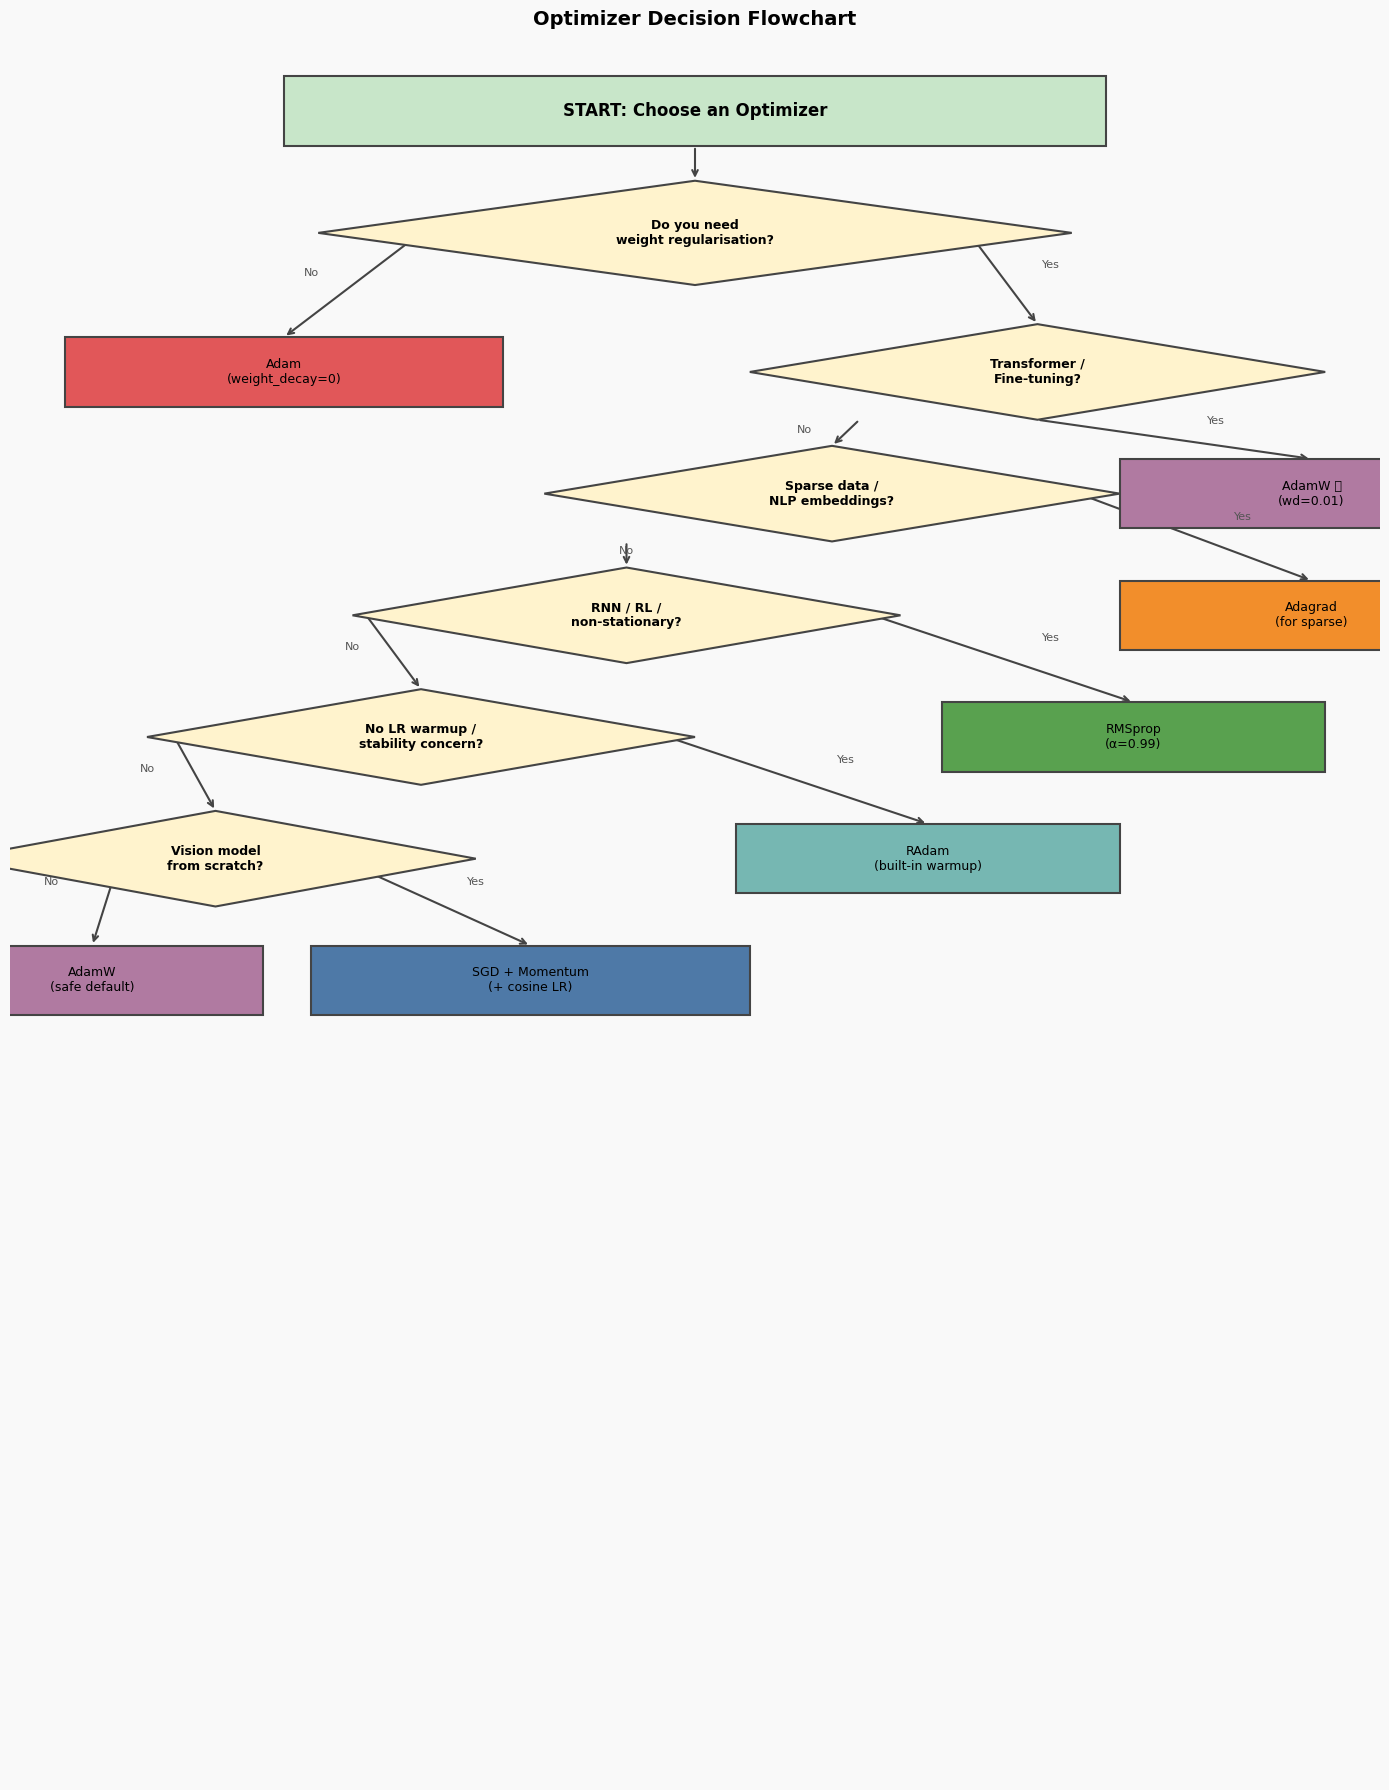

In [10]:
fig, ax = plt.subplots(figsize=(14, 18))
ax.set_xlim(0, 10); ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('#f9f9f9')

def box(ax, x, y, w, h, text, color='#dce8f5', fontsize=10, bold=False):
    rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                          facecolor=color, edgecolor='#444', linewidth=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold' if bold else 'normal', wrap=True,
            multialignment='center', zorder=3)

def diamond(ax, x, y, w, h, text, color='#fff3cd', fontsize=9):
    pts = np.array([[x, y+h/2],[x+w/2, y],[x, y-h/2],[x-w/2, y],[x, y+h/2]])
    ax.fill(pts[:,0], pts[:,1], color=color, edgecolor='#444', linewidth=1.5, zorder=2)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', multialignment='center', zorder=3)

def arrow(ax, x1, y1, x2, y2, label='', lx=None, ly=None):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.5), zorder=1)
    if label:
        lx = lx if lx else (x1+x2)/2
        ly = ly if ly else (y1+y2)/2
        ax.text(lx, ly, label, fontsize=8, color='#555', ha='center')

# ── Nodes ──────────────────────────────────────────────────
box(ax, 5, 19.2, 6, 0.8, 'START: Choose an Optimizer', color='#c8e6c9', fontsize=12, bold=True)

diamond(ax, 5, 17.8, 5.5, 1.2, 'Do you need\nweight regularisation?')
box(ax, 2.0, 16.2, 3.2, 0.8, 'Adam\n(weight_decay=0)', color='#e15759', fontsize=9)

diamond(ax, 7.5, 16.2, 4.2, 1.1, 'Transformer /\nFine-tuning?')
box(ax, 9.5, 14.8, 2.8, 0.8, 'AdamW ✅\n(wd=0.01)', color='#b07aa1', fontsize=9)

diamond(ax, 6.0, 14.8, 4.2, 1.1, 'Sparse data /\nNLP embeddings?')
box(ax, 9.5, 13.4, 2.8, 0.8, 'Adagrad\n(for sparse)', color='#f28e2b', fontsize=9)

diamond(ax, 4.5, 13.4, 4.0, 1.1, 'RNN / RL /\nnon-stationary?')
box(ax, 8.2, 12.0, 2.8, 0.8, 'RMSprop\n(α=0.99)', color='#59a14f', fontsize=9)

diamond(ax, 3.0, 12.0, 4.0, 1.1, 'No LR warmup /\nstability concern?')
box(ax, 6.7, 10.6, 2.8, 0.8, 'RAdam\n(built-in warmup)', color='#76b7b2', fontsize=9)

diamond(ax, 1.5, 10.6, 3.8, 1.1, 'Vision model\nfrom scratch?')
box(ax, 3.8, 9.2, 3.2, 0.8, 'SGD + Momentum\n(+ cosine LR)', color='#4e79a7', fontsize=9)
box(ax, 0.6, 9.2, 2.5, 0.8, 'AdamW\n(safe default)', color='#b07aa1', fontsize=9)

# ── Arrows ─────────────────────────────────────────────────
arrow(ax, 5,   18.8, 5,   18.4)                       # start -> Q1
arrow(ax, 3.0, 17.8, 2.0, 16.6, 'No',  lx=2.2, ly=17.3)
arrow(ax, 7.0, 17.8, 7.5, 16.75, 'Yes', lx=7.6, ly=17.4)
arrow(ax, 7.5, 15.65, 9.5, 15.2, 'Yes', lx=8.8, ly=15.6)
arrow(ax, 6.2, 15.65, 6.0, 15.35, 'No',  lx=5.8, ly=15.5)
arrow(ax, 7.8, 14.8, 9.5, 13.8, 'Yes', lx=9.0, ly=14.5)
arrow(ax, 4.5, 14.25, 4.5, 13.95, 'No')
arrow(ax, 6.3, 13.4, 8.2, 12.4, 'Yes', lx=7.6, ly=13.1)
arrow(ax, 2.6, 13.4, 3.0, 12.55, 'No',  lx=2.5, ly=13.0)
arrow(ax, 4.8, 12.0, 6.7, 11.0, 'Yes', lx=6.1, ly=11.7)
arrow(ax, 1.2, 12.0, 1.5, 11.15, 'No',  lx=1.0, ly=11.6)
arrow(ax, 2.4, 10.6, 3.8, 9.6, 'Yes', lx=3.4, ly=10.3)
arrow(ax, 0.8, 10.6, 0.6, 9.6, 'No',  lx=0.3, ly=10.3)

ax.set_title('Optimizer Decision Flowchart', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_decision_flowchart.png', dpi=130, bbox_inches='tight')
plt.show()

---
## § 8 — Final Cheat Sheet

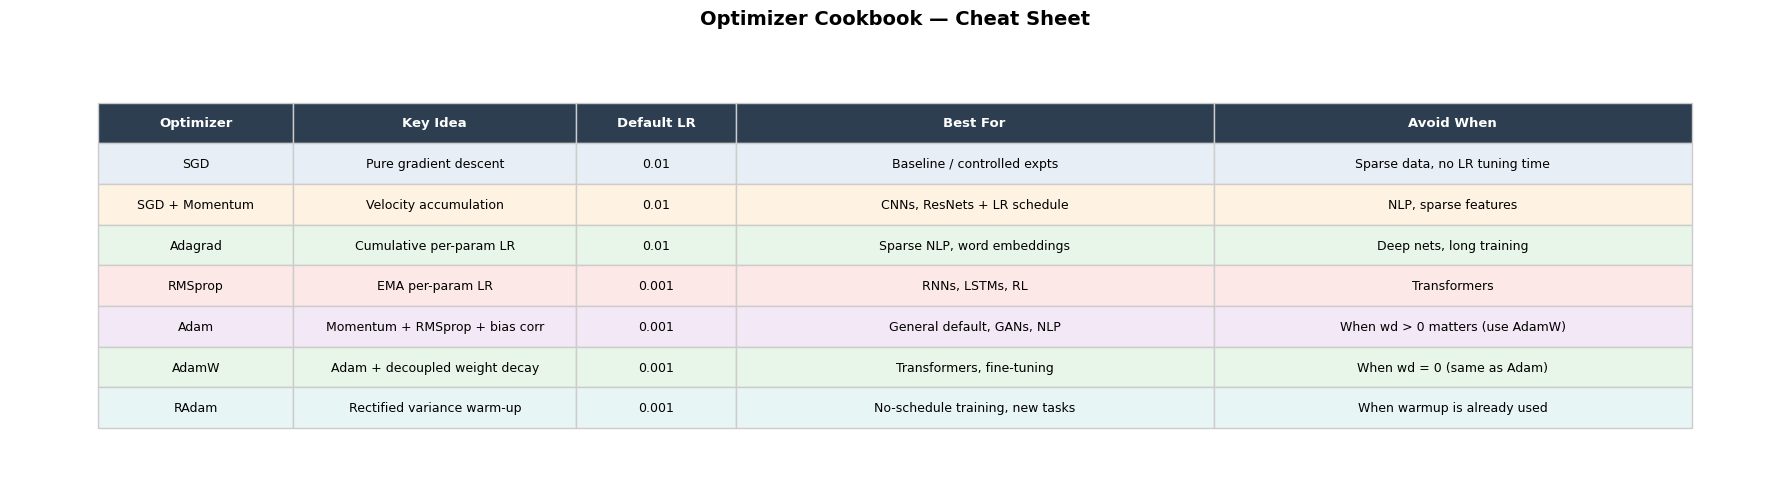

Saved → results/plots/final_cheatsheet.png


In [13]:
cheatsheet = [
    ['Optimizer',       'Key Idea',                        'Default LR', 'Best For',                        'Avoid When'],
    ['SGD',             'Pure gradient descent',           '0.01',       'Baseline / controlled expts',      'Sparse data, no LR tuning time'],
    ['SGD + Momentum',  'Velocity accumulation',           '0.01',       'CNNs, ResNets + LR schedule',      'NLP, sparse features'],
    ['Adagrad',         'Cumulative per-param LR',         '0.01',       'Sparse NLP, word embeddings',      'Deep nets, long training'],
    ['RMSprop',         'EMA per-param LR',                '0.001',      'RNNs, LSTMs, RL',                  'Transformers'],
    ['Adam',            'Momentum + RMSprop + bias corr',  '0.001',      'General default, GANs, NLP',       'When wd > 0 matters (use AdamW)'],
    ['AdamW',           'Adam + decoupled weight decay',   '0.001',      'Transformers, fine-tuning',        'When wd = 0 (same as Adam)'],
    ['RAdam',           'Rectified variance warm-up',      '0.001',      'No-schedule training, new tasks',  'When warmup is already used'],
]

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')

header = cheatsheet[0]
body   = cheatsheet[1:]
col_w  = [0.11, 0.16, 0.09, 0.27, 0.27]

# Colors correspond to the 7 body rows (not the header row).
row_colors_list = [
    ['#e8eef5'] * 5,
    ['#fef3e2'] * 5,
    ['#e8f5e9'] * 5,
    ['#fde8e8'] * 5,
    ['#f3e8f5'] * 5,
    ['#e8f5e9'] * 5,
    ['#e8f5f5'] * 5,
]

table = ax.table(
    cellText    = body,
    colLabels   = header,
    cellLoc     = 'center',
    loc         = 'center',
    colWidths   = col_w,
    cellColours = row_colors_list,
 )
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold', fontsize=9.5)
    cell.set_edgecolor('#cccccc')

ax.set_title('Optimizer Cookbook — Cheat Sheet', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/final_cheatsheet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/plots/final_cheatsheet.png')

---
## § 9 — All Plots Generated — Summary

In [14]:
all_plots = [
    ('00', 'cifar10_sample.png',               'CIFAR-10 sample batch'),
    ('00', 'SGD_baseline_curves.png',          'Vanilla SGD training curves'),
    ('01', 'SGD_Momentum_curves.png',          'SGD + Momentum training curves'),
    ('01', 'momentum_sensitivity.png',         'Momentum β sensitivity sweep'),
    ('01', 'SGD_vs_Momentum.png',              'SGD vs SGD+Momentum comparison'),
    ('02', 'Adagrad_curves.png',               'Adagrad training curves'),
    ('02', 'Adagrad_lr_decay.png',             'Adagrad dying LR visualisation'),
    ('02', 'comparison_up_to_adagrad.png',     'Cumulative comparison (up to Adagrad)'),
    ('03', 'RMSprop_curves.png',               'RMSprop training curves'),
    ('03', 'RMSprop_alpha_sensitivity.png',    'RMSprop α sensitivity sweep'),
    ('03', 'comparison_up_to_rmsprop.png',     'Cumulative comparison (up to RMSprop)'),
    ('04', 'Adam_curves.png',                  'Adam training curves'),
    ('04', 'Adam_bias_correction.png',         'Adam bias correction visualisation'),
    ('04', 'Adam_lr_sensitivity.png',          'Adam LR sensitivity sweep'),
    ('04', 'Adam_gradient_norms.png',          'Adam gradient norm tracking'),
    ('04', 'comparison_up_to_adam.png',        'Cumulative comparison (up to Adam)'),
    ('05', 'AdamW_curves.png',                 'AdamW training curves'),
    ('05', 'AdamW_decoupled_weight_decay.png', 'Decoupled WD visualisation'),
    ('05', 'Adam_vs_AdamW_comparison.png',     'Adam vs AdamW direct comparison'),
    ('05', 'AdamW_wd_sensitivity.png',         'AdamW weight decay sweep'),
    ('06', 'RAdam_curves.png',                 'RAdam training curves'),
    ('06', 'RAdam_rectification_term.png',     'RAdam rectification term analysis'),
    ('06', 'RAdam_vs_Adam_early.png',          'RAdam vs Adam early epoch comparison'),
    ('06', 'RAdam_lr_robustness.png',          'RAdam LR robustness test'),
    ('07', 'final_all_curves.png',             'Full comparison — all 7 optimizers'),
    ('07', 'final_leaderboard_bar.png',        'Final leaderboard bar chart'),
    ('07', 'final_convergence_speed.png',      'Convergence speed heatmap'),
    ('07', 'final_generalisation_gap.png',     'Generalisation gap chart'),
    ('07', 'final_compute_efficiency.png',     'Compute efficiency chart'),
    ('07', 'final_radar_chart.png',            'Radar chart — optimizer profiles'),
    ('07', 'final_decision_flowchart.png',     'Decision flowchart'),
    ('07', 'final_cheatsheet.png',             'Final cheat sheet'),
]

print(f"{'Ch':>3}  {'File':<45} {'Status':>10}  Description")
print('-' * 90)
found, total = 0, 0
for ch, fname, desc in all_plots:
    path   = f'{PLOTS_DIR}/{fname}'
    status = '✅ found' if os.path.exists(path) else '⚠️  missing'
    if os.path.exists(path): found += 1
    total += 1
    print(f'{ch:>3}  {fname:<45} {status:>10}  {desc}')

print('-' * 90)
print(f'\n{found}/{total} plots generated.')
if found == total:
    print('\n🎉 Cookbook complete! All plots saved to results/plots/')
else:
    print(f'\nRun missing notebooks to generate remaining {total - found} plots.')

 Ch  File                                              Status  Description
------------------------------------------------------------------------------------------
 00  cifar10_sample.png                               ✅ found  CIFAR-10 sample batch
 00  SGD_baseline_curves.png                          ✅ found  Vanilla SGD training curves
 01  SGD_Momentum_curves.png                          ✅ found  SGD + Momentum training curves
 01  momentum_sensitivity.png                         ✅ found  Momentum β sensitivity sweep
 01  SGD_vs_Momentum.png                              ✅ found  SGD vs SGD+Momentum comparison
 02  Adagrad_curves.png                               ✅ found  Adagrad training curves
 02  Adagrad_lr_decay.png                             ✅ found  Adagrad dying LR visualisation
 02  comparison_up_to_adagrad.png                     ✅ found  Cumulative comparison (up to Adagrad)
 03  RMSprop_curves.png                               ✅ found  RMSprop training curves
 03  RMSp

---

## 🎉 Cookbook Complete!

### What You Built

A full empirical optimizer study with **7 optimizers**, **32 plots**, and a complete narrative arc:

```
SGD  →  fixed LR, slow, baseline
  + Momentum  →  faster, direction-aware
    Adagrad   →  per-param LR, but dies
      RMSprop →  fixes dying LR with EMA
        Adam  →  momentum + RMSprop + bias correction
          AdamW →  decouples weight decay properly
            RAdam →  built-in variance warmup
```

### Recommended Citation Format
```
Optimizer Cookbook — Empirical Comparison on CIFAR-10
Model: SimpleCNN (3-layer, BatchNorm, Dropout=0.3)
Dataset: CIFAR-10 (50k train / 10k test)
Epochs: 20 | Batch: 128 | Seed: 42
Framework: PyTorch | Hardware: NVIDIA GPU (CUDA)
```

### Next Steps
- Extend to **ResNet-18** and compare results
- Add **learning rate schedulers** (cosine annealing, OneCycleLR)
- Experiment with **LAMB / LARS** for large-batch settings
- Try newer optimizers: **Sophia**, **Muon**, **Schedule-Free Adam**